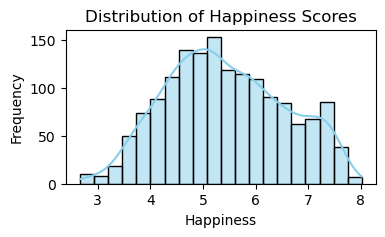

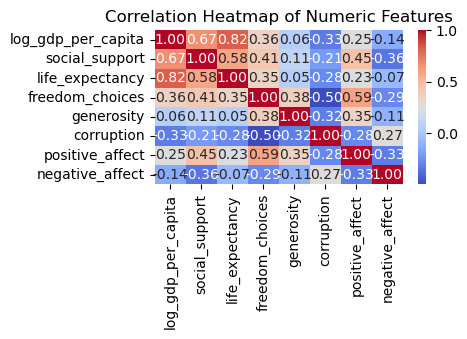

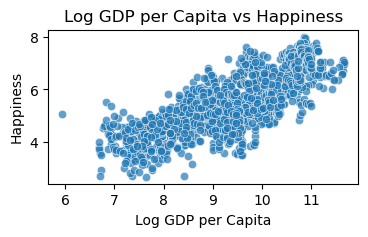

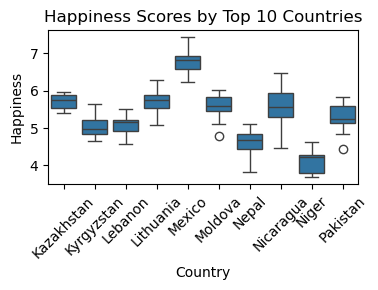

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
train = pd.read_csv('final_project_data/train.csv')

# Visualization 1: Distribution of Happiness Scores
plt.figure(figsize=(4, 2))
sns.histplot(train['happiness'], bins=20, kde=True, color='skyblue')
plt.title('Distribution of Happiness Scores')
plt.xlabel('Happiness')
plt.ylabel('Frequency')
plt.show()

# Visualization 2: Correlation Heatmap
plt.figure(figsize=(4, 2))
numeric_features = [
    'log_gdp_per_capita', 'social_support', 'life_expectancy',
    'freedom_choices', 'generosity', 'corruption', 
    'positive_affect', 'negative_affect'
]
corr_matrix = train[numeric_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

# Visualization 3: Scatter Plot of GDP vs Happiness
plt.figure(figsize=(4, 2))
sns.scatterplot(x=train['log_gdp_per_capita'], y=train['happiness'], alpha=0.7)
plt.title('Log GDP per Capita vs Happiness')
plt.xlabel('Log GDP per Capita')
plt.ylabel('Happiness')
plt.show()

# Visualization 4: Box Plot of Happiness by Country (Top 10 Countries by Frequency)
top_countries = train['country'].value_counts().nlargest(10).index
filtered_data = train[train['country'].isin(top_countries)]
plt.figure(figsize=(4, 2))
sns.boxplot(x='country', y='happiness', data=filtered_data)
plt.title('Happiness Scores by Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Happiness')
plt.xticks(rotation=45)
plt.show()


In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, ReLU
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import mean_squared_error

# Set random seeds for reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Load data
train = pd.read_csv('final_project_data/train.csv')
test = pd.read_csv('final_project_data/test.csv')

def preprocess_data(df, is_train=True):
    data = df.copy()
    
    # Feature Engineering
    data['log_gdp_per_capita'] = np.log1p(data['log_gdp_per_capita'])
    data['log_generosity'] = np.log1p(data['generosity'] + 1e-3)
    data['economic_wellbeing'] = data['log_gdp_per_capita'] * data['social_support']
    data['life_quality'] = data['life_expectancy'] * data['freedom_choices']
    
    # Feature Selection
    numeric_features = [
        'log_gdp_per_capita', 'social_support', 'life_expectancy',
        'freedom_choices', 'log_generosity', 'corruption', 
        'positive_affect', 'negative_affect', 
        'economic_wellbeing', 'life_quality'
    ]
    
    if is_train:
        y = data['happiness']
        X = data.drop(['happiness', 'ID'], axis=1)
    else:
        X = data.drop('ID', axis=1)
        y = None
    
    categorical_features = ['country']
    
    # Preprocessing Pipeline
    numeric_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ])
    
    if is_train:
        return X, y, preprocessor
    else:
        return X, preprocessor

# Preprocess the training data
X, y, preprocessor = preprocess_data(train)

# Fit the preprocessor and transform the training data
X_transformed = preprocessor.fit_transform(X)

# Split the transformed data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_transformed, y, test_size=0.2, random_state=seed)

# Define the optimized Neural Network model
def build_optimized_model(input_dim):
    model = Sequential([
        Dense(512, input_dim=input_dim),
        ReLU(),
        BatchNormalization(),
        Dropout(0.2),
        Dense(256),
        ReLU(),
        BatchNormalization(),
        Dropout(0.2),
        Dense(128),
        ReLU(),
        BatchNormalization(),
        Dropout(0.1),
        Dense(64),
        ReLU(),
        BatchNormalization(),
        Dense(1, activation='linear')
    ])
    model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mse'])
    return model

# Build and compile the model
input_dim = X_train.shape[1]
model = build_optimized_model(input_dim)

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=25, verbose=1, min_lr=1e-6)
model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',  # Save in .keras format
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5500,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

# Load the best model
import os
from tensorflow.keras.models import load_model

# Check if the model file exists and load it
if os.path.exists('best_model.keras'):
    best_model = load_model('best_model.keras')
    print("Best model loaded successfully.")
else:
    print("Best model file not found. Check ModelCheckpoint settings.")



# Evaluate on validation data
y_val_pred = best_model.predict(X_val)
mse = mean_squared_error(y_val, y_val_pred)
print("\nValidation MSE:", mse)

# Preprocess the test data using the fitted preprocessor
X_test, _ = preprocess_data(test, is_train=False)
X_test_transformed = preprocessor.transform(X_test)

# Predict on test data
test_predictions = best_model.predict(X_test_transformed).flatten()

# Create a submission file
submission = pd.DataFrame({
    'ID': test['ID'],
    'happiness': test_predictions
})
submission.to_csv('submission.csv', index=False)
print("\nSubmission file created!")


Epoch 1/5500


/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


34/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 30.3905 - mse: 30.3905
Epoch 1: val_loss improved from inf to 27.21054, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 30.0427 - mse: 30.0427 - val_loss: 27.2105 - val_mse: 27.2105 - learning_rate: 0.0010
Epoch 2/5500
34/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 24.7618 - mse: 24.7618
Epoch 2: val_loss improved from 27.21054 to 20.74762, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24.4657 - mse: 24.4657 - val_loss: 20.7476 - val_mse: 20.7476 - learning_rate: 0.0010
Epoch 3/5500
31/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18.9228 - mse: 18.9228
Epoch 3: val_loss improved from 20.74762 to 13.32954, saving model to best_model.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.3926 - mse: 18.3926 - val_loss: 13.3295 - val_mse: 13.3295 - learning_rate: 0.0010
Epoch 4/5500
37/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 11.4874 - mse: 11.4874
Epoch 4: val_loss improved